In [113]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, regularizers


In [114]:
DIM_NAMES = ['Length', 'Diameter', 'Slot_Length', 'Slot_Width', 'Throat_Diameter', 'Exit_Diameter']

NUM_POINTS = 100# Total input dimension will be 400 (200 Thrust + 200 Pressure)

def process_data_inverse(file_path, num_points=NUM_POINTS):
    df = pd.read_csv(file_path, on_bad_lines='skip', skip_blank_lines=True, low_memory=False)
    df.columns = df.columns.str.strip()

    # Numeric conversion and cleaning
    target_cols = ['ID', 'Time (s)', 'Thrust (N)', 'Pressure (MPa)'] + DIM_NAMES
    for col in target_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    df.dropna(inplace=True)

    ids = df['ID'].unique()
    X_profiles, y_dims = [], []

    for uid in ids:
        try:
            case_data = df[df['ID'] == uid].sort_values('Time (s)')
            dims = case_data[DIM_NAMES].iloc[0].values.astype(float)

            t = case_data['Time (s)'].values
            thrust = case_data['Thrust (N)'].values
            pressure = case_data['Pressure (MPa)'].values

            if len(t) < 10 or t[-1] <= 0: continue

            # Curve smoothing
            thrust = savgol_filter(thrust, 7, 3)
            pressure = savgol_filter(pressure, 7, 3)

            # Interpolation to fixed length
            t_new = np.linspace(t[0], t[-1], num_points)
            thrust_interp = interp1d(t, thrust, kind='linear', fill_value='extrapolate')(t_new)
            pressure_interp = interp1d(t, pressure, kind='linear', fill_value='extrapolate')(t_new)

            # Merge both profiles into one input vector
            X_profiles.append(np.concatenate([thrust_interp, pressure_interp]))
            y_dims.append(dims)
        except:
            continue

    return np.array(X_profiles), np.array(y_dims)

# Execute processing
FILE_PATH = '/kaggle/input/datasets/abdoamrrrr/x-grain/Rocket_Results_Full_Data.csv'
X_all, y_all = process_data_inverse(FILE_PATH)
print(f"X shape: {X_all.shape}, y shape: {y_all.shape}")

X shape: (3383, 200), y shape: (3383, 6)


In [115]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.15, random_state=42)

scaler_X = RobustScaler()
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train)
X_test_s = scaler_X.transform(X_test)
y_train_s = scaler_y.fit_transform(y_train)
y_test_s = scaler_y.transform(y_test)

# Save scalers for future inference
joblib.dump(scaler_X, 'scaler_X_inverse.pkl')
joblib.dump(scaler_y, 'scaler_y_inverse.pkl')
print("✅ Scalers saved.")

✅ Scalers saved.


In [116]:
from tensorflow.keras import regularizers

def build_inverse_model(input_dim, output_dim=len(DIM_NAMES)):
    # Weight Regularization factor to prevent overfitting
    l2_reg = 0.001 
    
    inp = layers.Input(shape=(input_dim,), name='Curves_Input')

    # Step 1: Add Noise to Inputs (Acts as Data Augmentation)
    x = layers.GaussianNoise(0.01)(inp)
    x = layers.Reshape((input_dim, 1))(x)

    # Step 2: Feature Extraction using 1D-CNN
    x = layers.Conv1D(64, 7, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 5, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = layers.GlobalAveragePooling1D()(x)

    # Step 3: Residual Block with L2 and Simplified Architecture
    res1 = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(x)
    res1 = layers.BatchNormalization()(res1)
    res1 = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(res1)
    
    # Ensuring shortcut matches the dimensions with a Dense layer
    shortcut1 = layers.Dense(256, kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.Add()([shortcut1, res1])
    x = layers.Dropout(0.5)(x) 

    # Step 4: Multi-head output for each dimension
    heads = []
    for i in range(output_dim):
        # Increased head capacity for the first 4 difficult dimensions
        head_units = 128 if i < 4 else 64
        h = layers.Dense(head_units, activation='relu')(x)
        h = layers.Dropout(0.2)(h) # Balanced dropout for head stability
        h = layers.Dense(1)(h)
        heads.append(h)

    out = layers.Concatenate(name='Dimensions_Output')(heads)

    model = models.Model(inputs=inp, outputs=out, name='Inverse_Rocket_Model_Final')
    return model

# Initialize and Compile
model_inverse = build_inverse_model(input_dim=X_all.shape[1])
model_inverse.compile(
    optimizer=optimizers.Adam(learning_rate=0.0005), 
    loss='huber', 
    metrics=['mae']
)

model_inverse.summary()

Model: "Inverse_Rocket_Model_Final"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Curves_Input        │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise_16   │ (None, 200)       │          0 │ Curves_Input[0][… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_16          │ (None, 200, 1)    │          0 │ gaussian_noise_1… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_48 (Conv1D)  │ (None, 200, 64)   │        512 │ reshape_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 64)   │        256 │ conv1d_48[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_49 (Conv1D)  │ (None, 200, 128)  │     41,088 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 128)  │        512 │ conv1d_49[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_50 (Conv1D)  │ (None, 200, 128)  │     49,280 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ conv1d_50[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_240 (Dense)   │ (None, 256)       │     33,024 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_240[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_242 (Dense)   │ (None, 256)       │     33,024 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_241 (Dense)   │ (None, 256)       │     65,792 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_16 (Add)        │ (None, 256)       │          0 │ dense_242[0][0],  │
│                     │                   │            │ dense_241[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_112         │ (None, 256)       │          0 │ add_16[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_243 (Dense)   │ (None, 128)       │     32,896 │ dropout_112[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_245 (Dense)   │ (None, 128)       │     32,896 │ dropout_112[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_247 (Dense)   │ (None, 128)       │     32,896 │ dropout_112[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_249 (Dense)   │ (None, 128)       │     32,896 │ dropout_112[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_251 (Dense)   │ (None, 64)        │     16,448 │ dropout_112[0][0] │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 389,638 (1.49 MB)

 Trainable params: 388,742 (1.48 MB)

 Non-trainable params: 896 (3.50 KB)

In [117]:
# Callbacks
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15, min_lr=0.00001, verbose=1)

# Training
history = model_inverse.fit(
    X_train_s, y_train_s,
    validation_split=0.15,
    epochs=500,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Model Persistence
model_inverse.save('inverse_rocket_model.h5')

# Performance Metrics
y_pred_s = model_inverse.predict(X_test_s)
y_pred = scaler_y.inverse_transform(y_pred_s)


Epoch 1/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 21s 115ms/step - loss: 1.1247 - mae: 0.9345 - val_loss: 0.9658 - val_mae: 0.8132 - learning_rate: 5.0000e-04
Epoch 2/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.9358 - mae: 0.7817 - val_loss: 0.9079 - val_mae: 0.7952 - learning_rate: 5.0000e-04
Epoch 3/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.8663 - mae: 0.7517 - val_loss: 0.8574 - val_mae: 0.7787 - learning_rate: 5.0000e-04
Epoch 4/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.8110 - mae: 0.7282 - val_loss: 0.8131 - val_mae: 0.7704 - learning_rate: 5.0000e-04
Epoch 5/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.7707 - mae: 0.7217 - val_loss: 0.7615 - val_mae: 0.7455 - learning_rate: 5.0000e-04
Epoch 6/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.7167 - mae: 0.6934 - val_loss: 0.7080 - val_mae: 0.7130 - learning_rate: 5.0000e-04
Epoch 7/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6833 - mae: 0.6858 - val_loss: 0.6895 - val_mae: 0.7231 - learning

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step 


In [118]:
# Print accuracy for each dimension
print("\nAccuracy Summary (MAPE per Dimension):")
mape_errors = []

for i, name in enumerate(DIM_NAMES):
    # Calculate Mean Absolute Percentage Error (MAPE)
    error = np.mean(np.abs((y_test[:, i] - y_pred[:, i]) / y_test[:, i])) * 100
    mape_errors.append(error)
    print(f"- {name:<20}: {error:.2f}%")

# Calculate and print total average MAPE
total_mape = np.mean(mape_errors)
print(f"\nTotal Average MAPE: {total_mape:.2f}%")


Accuracy Summary (MAPE per Dimension):
- Length              : 9.59%
- Diameter            : 9.80%
- Slot_Length         : 9.88%
- Slot_Width          : 9.80%
- Throat_Diameter     : 1.18%
- Exit_Diameter       : 1.20%

Total Average MAPE: 6.91%


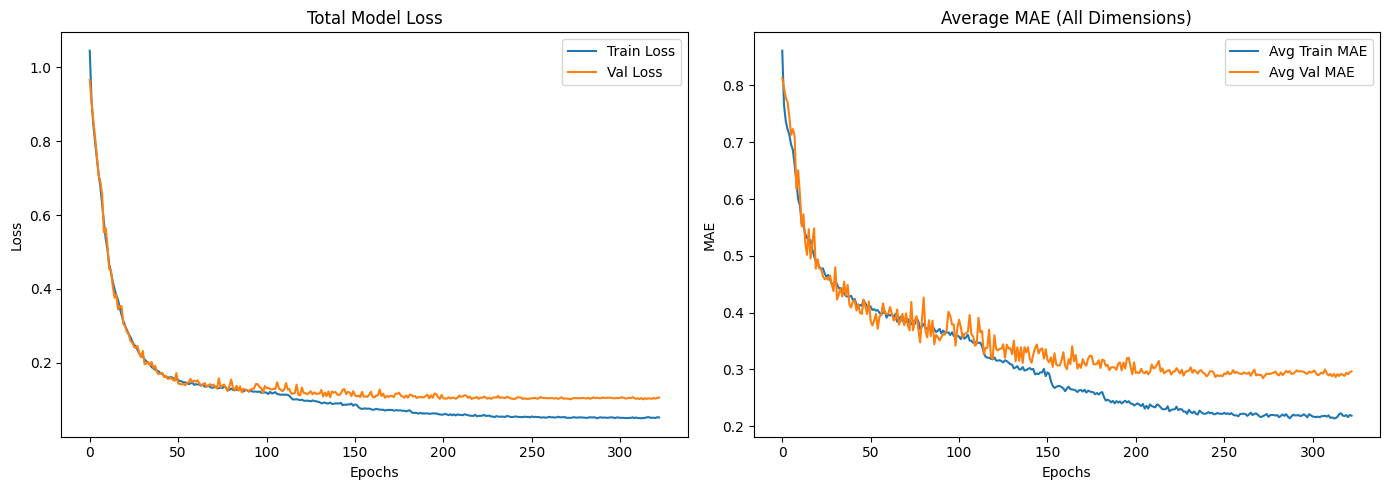

In [119]:
# Set figure size for two side-by-side plots
plt.figure(figsize=(14, 5))

# --- Part 1: Plot Total Model Loss ---
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Total Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# --- Part 2: Plot Average Mean Absolute Error (MAE) for all dimensions ---
plt.subplot(1, 2, 2)

# Extract MAE keys for all outputs from the training history
# Non-validation keys
mae_keys = [k for k in history.history.keys() if 'mae' in k and 'val' not in k]
# Validation keys
val_mae_keys = [k for k in history.history.keys() if 'mae' in k and 'val' in k]

# Calculate the mean across all output heads and plot
if mae_keys:
    avg_train_mae = np.mean([history.history[k] for k in mae_keys], axis=0)
    plt.plot(avg_train_mae, label='Avg Train MAE')

if val_mae_keys:
    avg_val_mae = np.mean([history.history[k] for k in val_mae_keys], axis=0)
    plt.plot(avg_val_mae, label='Avg Val MAE')

plt.title('Average MAE (All Dimensions)')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()

# Display the plots
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
--- Testing Inverse Model Prediction (Index: 501) ---
Dimension            | Actual       | Predicted    | Error %
----------------------------------------------------------------------
Length               | 70.0000      | 70.3076      | 0.44%
Diameter             | 14.0000      | 14.1697      | 1.21%
Slot_Length          | 2.5000       | 2.5419       | 1.68%
Slot_Width           | 2.4000       | 2.4072       | 0.30%
Throat_Diameter      | 2.6000       | 2.6093       | 0.36%
Exit_Diameter        | 3.9000       | 3.9146       | 0.37%


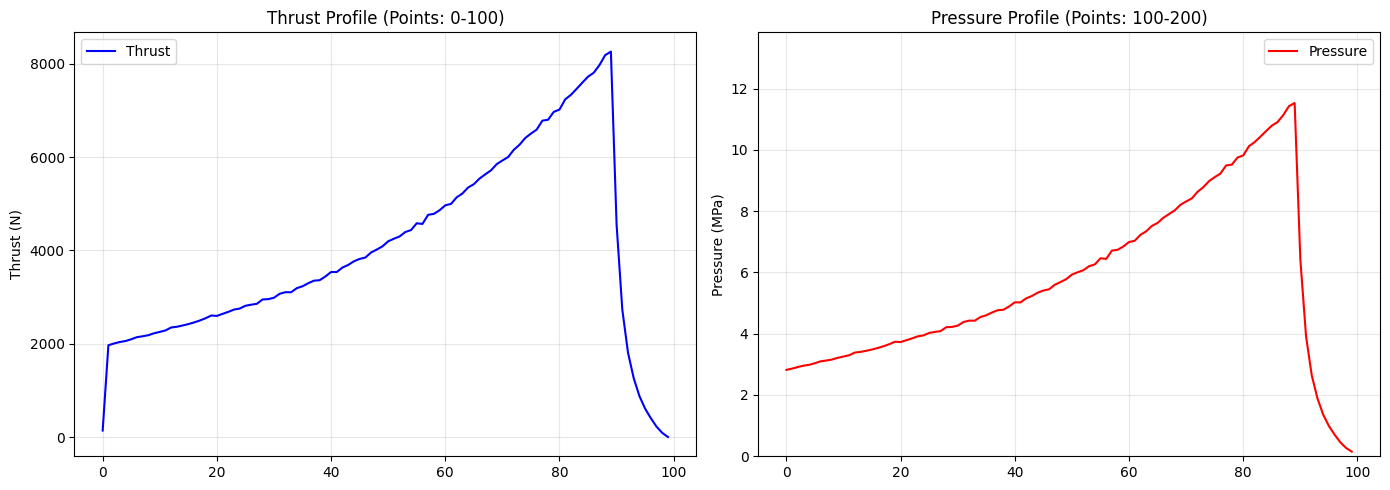

In [127]:
# --- Final Corrected Test Cell ---
# 1. Select sample and predict
test_index = np.random.randint(0, len(X_test_s))
sample_input = X_test_s[test_index : test_index + 1]
actual_dims = y_test[test_index]

predicted_dims_scaled = model_inverse.predict(sample_input)
predicted_dims = scaler_y.inverse_transform(predicted_dims_scaled)[0]

# 2. Print Evaluation Table
print(f"--- Testing Inverse Model Prediction (Index: {test_index}) ---")
print(f"{'Dimension':<20} | {'Actual':<12} | {'Predicted':<12} | {'Error %'}")
print("-" * 70)
for i, name in enumerate(DIM_NAMES):
    error = abs(actual_dims[i] - predicted_dims[i]) / actual_dims[i] * 100
    print(f"{name:<20} | {actual_dims[i]:<12.4f} | {predicted_dims[i]:<12.4f} | {error:.2f}%")

# 3. Visualization
plt.figure(figsize=(14, 5))
full_data = X_test[test_index]
total_len = len(full_data)

# --- Thrust Plot ---
plt.subplot(1, 2, 1)
mid_point = total_len // 2
plt.plot(full_data[:mid_point], color='blue', label='Thrust')
plt.title(f"Thrust Profile (Points: 0-{mid_point})")
plt.ylabel("Thrust (N)")
plt.legend()
plt.grid(True, alpha=0.3)

# --- Pressure Plot with Safety Check ---
plt.subplot(1, 2, 2)
if total_len > mid_point:
    pressure_data = full_data[mid_point:]
    plt.plot(pressure_data, color='red', label='Pressure')
    if pressure_data.size > 0 and np.max(pressure_data) > 0:
        plt.ylim(0, np.max(pressure_data) * 1.2)
    plt.title(f"Pressure Profile (Points: {mid_point}-{total_len})")
    plt.legend()
else:
    plt.text(0.5, 0.5, "Data Missing: Array too small", ha='center')
    plt.title("Pressure Profile (Empty)")

plt.ylabel("Pressure (MPa)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [128]:
# --- Cell: Save the Inverse Model and Scalers ---

# 1. Save the trained Keras model
# It is recommended to use 'inverse_rocket_model.h5' or 'inverse_rocket_model.keras'
model_inverse.save('inverse_rocket_model.h5')
print("✅ Trained model saved successfully as 'inverse_rocket_model.h5'")

# 2. Save the Scalers
# These are essential to transform new input data and reverse-transform predictions
import joblib

joblib.dump(scaler_X, 'scaler_X_inverse.pkl')
joblib.dump(scaler_y, 'scaler_y_inverse.pkl')
print("✅ Scalers saved successfully as '.pkl' files")

✅ Trained model saved successfully as 'inverse_rocket_model.h5'
✅ Scalers saved successfully as '.pkl' files
